In [1]:
import sys
sys.path.insert(0, '../../../src/CPM/')

from PertMain2 import Pert, Activity
import numpy as np
from datetime import datetime, time
import pandas as pd
from IPython.display import Image

In [2]:
N = 30

hourly_index = pd.date_range(start='2025-10-20 08:00', periods=N, freq='h')
resources = pd.DataFrame({'res1': 2*np.ones(N)}, index=hourly_index)
resources

,res1
2025-10-20 08:00:00,2.0
2025-10-20 09:00:00,2.0
2025-10-20 10:00:00,2.0
2025-10-20 11:00:00,2.0
2025-10-20 12:00:00,2.0
2025-10-20 13:00:00,2.0
2025-10-20 14:00:00,2.0
2025-10-20 15:00:00,2.0
2025-10-20 16:00:00,2.0
2025-10-20 17:00:00,2.0


In [3]:
start = Activity("start", duration=2, res={'res1':1})
a     = Activity("a",     duration=2, res={'res1':1})
b     = Activity("b",     duration=3, res={'res1':1})
c     = Activity("c",     duration=3, res={'res1':1})
d     = Activity("d",     duration=4, res={'res1':1})
e     = Activity("e",     duration=3, res={'res1':1})
f     = Activity("f",     duration=2, res={'res1':1})
g     = Activity("g",     duration=3, res={'res1':1})
h     = Activity("h",     duration=4, res={'res1':1})
end   = Activity("end",   duration=2, res={'res1':1})

graph = {start: [a, d, f],
         a: [b],
         b: [c],
         c: [g, h],
         d: [e],
         e: [c],
         f: [c],
         g: [end],
         h: [end],
         end:[]}

outageStartTime = datetime(2025, 10, 20, 8)

outage = Pert(graph, startTime=outageStartTime, resourcesTS=resources)

In [4]:
outage.calculateScheduleWithResources('max_use_res_act')

=====> Enough res: start
----------------
2025-10-20 08:00:00
wait      : ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'end']
candidates: ['start']
selected  : ['start']
ongoing   : ['start']
completed : []
no candidates
----------------
2025-10-20 09:00:00
wait      : ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'end']
candidates: []
selected  : ['start']
ongoing   : ['start']
completed : []
=====> Enough res: a
=====> Enough res: d
=====> Not enough res:  f
----------------
2025-10-20 10:00:00
wait      : ['b', 'c', 'e', 'f', 'g', 'h', 'end']
candidates: ['a', 'd', 'f']
selected  : ['a', 'd']
ongoing   : ['a', 'd']
completed : ['start']
=====> Not enough res:  f
----------------
2025-10-20 11:00:00
wait      : ['b', 'c', 'e', 'f', 'g', 'h', 'end']
candidates: ['f']
selected  : []
ongoing   : ['a', 'd']
completed : ['start']
=====> Enough res: b
=====> Not enough res:  f
----------------
2025-10-20 12:00:00
wait      : ['c', 'e', 'f', 'g', 'h', 'end']
candidates: ['b', 'f']
selected  : ['b']


/Users/mandd/projects/LOGOS/doc/demos/CPM/../../../src/CPM/PertMain2.py:735: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.optStatusDF = pd.concat([self.optStatusDF, new_elem], ignore_index=True)


In [5]:
outage.outageDF.to_dict()

{'actID': {0: 'start',
  1: 'a',
  2: 'b',
  3: 'c',
  4: 'd',
  5: 'e',
  6: 'f',
  7: 'g',
  8: 'h',
  9: 'end'},
 'start': {0: Timestamp('2025-10-20 08:00:00'),
  1: Timestamp('2025-10-20 10:00:00'),
  2: Timestamp('2025-10-20 12:00:00'),
  3: Timestamp('2025-10-20 17:00:00'),
  4: Timestamp('2025-10-20 10:00:00'),
  5: Timestamp('2025-10-20 14:00:00'),
  6: Timestamp('2025-10-20 15:00:00'),
  7: Timestamp('2025-10-20 20:00:00'),
  8: Timestamp('2025-10-20 20:00:00'),
  9: Timestamp('2025-10-21 00:00:00')},
 'end': {0: Timestamp('2025-10-20 10:00:00'),
  1: Timestamp('2025-10-20 12:00:00'),
  2: Timestamp('2025-10-20 15:00:00'),
  3: Timestamp('2025-10-20 20:00:00'),
  4: Timestamp('2025-10-20 14:00:00'),
  5: Timestamp('2025-10-20 17:00:00'),
  6: Timestamp('2025-10-20 17:00:00'),
  7: Timestamp('2025-10-20 23:00:00'),
  8: Timestamp('2025-10-21 00:00:00'),
  9: Timestamp('2025-10-21 02:00:00')},
 'delay': {0: 0.0,
  1: 0.0,
  2: 0.0,
  3: 0.0,
  4: 0.0,
  5: 0.0,
  6: 5.0,
  7: 0.

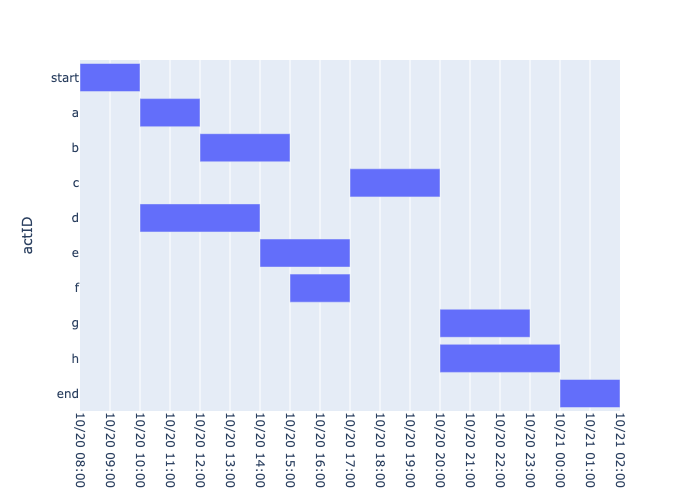

In [6]:
outage.plotGanttChart()
Image(filename='gantt.png') 

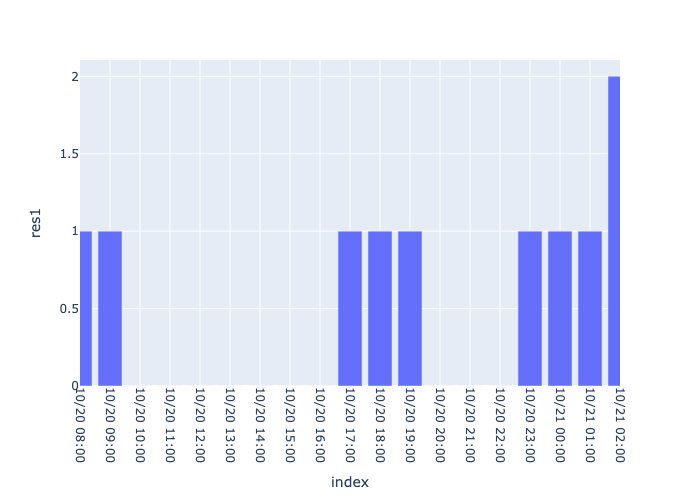

In [7]:
outage.plotResource('res1')
Image(filename='res1.png') 